In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
df=pd.read_csv("Exam_Score_Prediction.csv")
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,200.99,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,200.99,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,200.99,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,200.99,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,200.99,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  float64
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(5), int64(1), object(7)
memory usage: 2.0+ MB


In [3]:
df.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.500000,20.473300,4.007604,70.017365,7.00856,62.513225
std,5770.211372,2.284458,2.308313,17.282262,1.73209,18.908491
min,200.990000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,19800.010000,24.000000,7.910000,99.400000,9.90000,100.000000


In [4]:
df.isnull().sum()

student_id          0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

In [3]:
df.replace(["?", "N/A", "na", "None", ""], np.nan, inplace=True)

In [4]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols

['gender',
 'course',
 'internet_access',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty']

In [5]:
le = LabelEncoder()
df_encoded = df.copy()

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [6]:
num_cols = df_encoded.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('exam_score')  # keep target out of scaling now (optional)
num_cols

['student_id',
 'age',
 'gender',
 'course',
 'study_hours',
 'class_attendance',
 'internet_access',
 'sleep_hours',
 'sleep_quality',
 'study_method',
 'facility_rating',
 'exam_difficulty']

In [7]:
df_standard = df_encoded.copy()
df_minmax = df_encoded.copy()

In [8]:
scaler_std = StandardScaler()
df_standard[num_cols] = scaler_std.fit_transform(df_standard[num_cols])

In [9]:
scaler_mm = MinMaxScaler()
df_minmax[num_cols] = scaler_mm.fit_transform(df_minmax[num_cols])

In [10]:
df_final = df_minmax.copy()

In [11]:
X = df_final.drop(columns=['exam_score'])
y = df_final['exam_score']

In [12]:
corr = df_final.corr()
corr_with_target = corr['exam_score'].sort_values(ascending=False)
print(corr_with_target)

exam_score          1.000000
study_hours         0.717788
class_attendance    0.308850
sleep_hours         0.133222
age                 0.006522
exam_difficulty     0.003432
student_id          0.003267
gender             -0.000428
course             -0.000448
internet_access    -0.007826
facility_rating    -0.071879
sleep_quality      -0.099725
study_method       -0.154610
Name: exam_score, dtype: float64


In [13]:
selected_features = corr_with_target[abs(corr_with_target) >= 0.1].index.drop('exam_score').tolist()
selected_features

['study_hours', 'class_attendance', 'sleep_hours', 'study_method']

In [14]:
X_selected = X[selected_features]
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

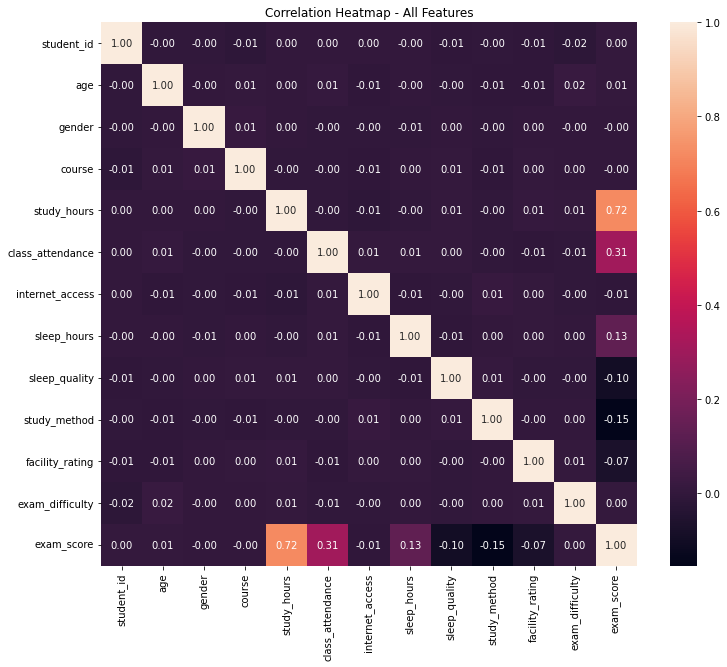

In [17]:
plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap - All Features")
plt.show()

This heatmap shows the relationship between every column in the dataset. The colors and numbers together show how strongly each variable is connected to the others. Most of the boxes are very light in color and the values are very close to 0, which clearly shows that many variables have little or no relationship with each other. For example, student_id has almost zero correlation with all columns, which means it is only an identification number and has no impact on exam score or learning behavior. Gender, course, internet access, facility rating, and exam difficulty also show values close to zero with exam_score, indicating that they do not significantly affect exam performance in this dataset.

The strongest color and highest value in this heatmap appear between study_hours and exam_score (around 0.72), showing a strong positive relationship. This means students who study more hours generally score higher in exams. Class_attendance and exam_score (around 0.31) show a moderate positive relationship, meaning students who attend classes more regularly tend to perform better. Sleep_hours shows a weak positive relationship (around 0.13), suggesting sleep has some effect but is not a major deciding factor. Study_method and sleep_quality show small negative values, meaning their effect on exam score is weak and slightly opposite. Overall, this heatmap is useful for understanding the dataset completely, because it allows us to study every variable at once, even those that are not useful for prediction.

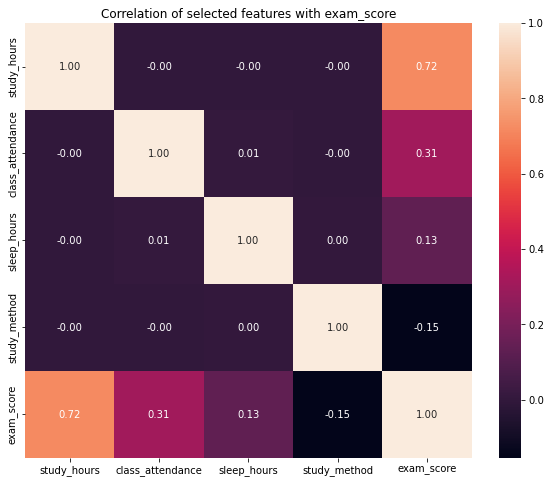

In [18]:
plt.figure(figsize=(10,8))
sns.heatmap(corr.loc[selected_features + ['exam_score'], selected_features + ['exam_score']], annot=True, fmt=".2f")
plt.title("Correlation of selected features with exam_score")
plt.show()

As most variables have no relation with exam_score (ex: student_id, gender, course → useless) which adds noise. to reduce overfitting, we are using only selected features/ important features. In graph the study_hours and exam_score have Strong positive correlation(0.72), More study hours = higher exam score thus it is the MOST important feature. Next  class_attendance & exam_score have Moderate positive correlation(0.31). thus attending class helps exam performance. Next sleep_hours & exam_score have Weak positive correlation(0.13) Thus sleep matters, but not a lot. Next study_method & exam_score have Negative correlation(-0.15) Thus some study methods may be less effective. Next sleep_quality & exam_score have Very weak negative correlation(-0.10) Thus it has No strong impact.
This heatmap is very useful for model building, because it removes noise and keeps only the features that truly matter for predicting exam scores. It gives a clear and focused understanding of what actually influences student performance.

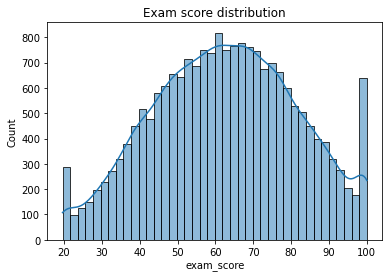

In [20]:
sns.histplot(df['exam_score'], kde=True)
plt.title('Exam score distribution')
plt.show()

This graph shows how exam marks are distributed among all students.It peaked near 60–70 which shows most students score average. Fewer students scored very low or very high compared to the middle range.
The shape is slightly spread out, meaning students have different performance levels.
There are a few extreme scores on the left or right side, these are outliers (very low or very high marks compared to most students).


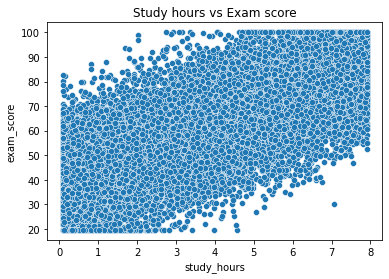

In [21]:
sns.scatterplot(x='study_hours', y='exam_score', data=df)
plt.title('Study hours vs Exam score')
plt.show()

Here each dot is a student, as it upward it shows a positive relationship, as study hours increase, exam scores goes higher i.e more study time is generally connected with higher marks. The spread of points is not perfectly tight, which means study hours influence score, but other factors matter too.
A few points fall far away from the main pattern, these are outliers
1.Students with high study hours but low marks.
2.Students with low study hours but high marks.

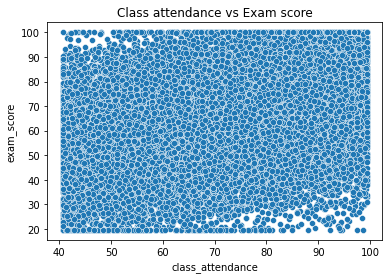

In [22]:
sns.scatterplot(x='class_attendance', y='exam_score', data=df)
plt.title('Class attendance vs Exam score')
plt.show()

The points cover almost the entire area of the graph.
There is no clear line, no upward trend, and no downward trend.
Students with any attendance level (40% to 100%) have all kinds of exam scores (from very low to very high). Students with high attendance did not always score high.
Students with low attendance did not always score low.
This means attendance alone does not predict exam performance in this dataset. the graph shows a cloud pattern, there is no positive or negative pattern. the outlier in here are some students who do well even if they attend fewer classes, and some attend all classes but still score poorly.

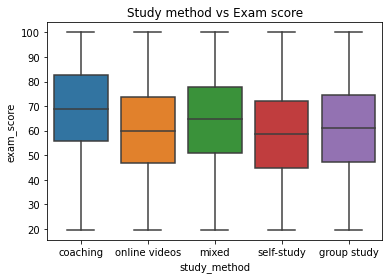

In [23]:
sns.boxplot(x='study_method', y='exam_score', data=df)
plt.title('Study method vs Exam score')
plt.show()

Each box represents one study method (e.g., coaching, online videos, mixed, self-study, group study). Some boxes are higher, meaning students using that method score higher on average.
Some boxes are lower, meaning students using that method score lower.
This shows study method affects exam performance. The line inside the box is the midian of exam score for that study method. The study method with the highest median line performs the best.
The method with the lowest median line performs the worst.

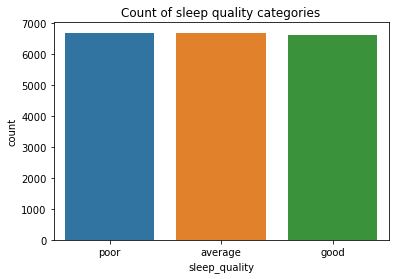

In [24]:
sns.countplot(x='sleep_quality', data=df)
plt.title('Count of sleep quality categories')
plt.show()

This bar plot shows the number of students in each sleep quality category. All bars are of equal height, which means each sleep quality category has the same number of students. This indicates that the dataset is evenly distributed and there is no dominance of any single sleep quality level. Because all categories have equal frequency, sleep quality does not show bias toward any particular group in the dataset. This balance is good for analysis because it ensures fair comparison between sleep quality categories and avoids skewed results.